In [15]:
import pandas as pd
import numpy as np
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv("survey.csv")

In [17]:
df.head()

,Timestamp,Reg No,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,12-4-2024 20:31:09,2341338,Data Scientist,3 LPA,1Cr,20 LPA,Deolite,3.0,4,20 LPA,60%,62%,77%,Industry
1,12-4-2024 20:33:07,2341310,Data Scientist,5,NaN,NaN,DE Shaw,3.0,2,11,67,60,97,Industry
2,12-4-2024 20:39:43,2341311,Data Scientist,7 LPA,15 LPA,8 LPA,DE Shaw,3.0,4,5 LPA,80,80,99,Research
3,12-4-2024 20:40:37,2341324,Data Scientist,3 LPA,25 LPA,10 LPA,DE Shaw,NaN,3,20,75,70,95,Research
4,12-4-2024 20:41:51,2341324,Business Analyst,2,50,25,Deolite,3.0,3,20,65,76,96,Industry


In [18]:
df.describe()

,Rate your contribution towards extra curricular activities,Rate your technical competencies
count,162.000000,163.000000
mean,3.382716,3.312883
std,1.109730,0.885560
min,1.000000,1.000000
25%,3.000000,3.000000
50%,3.000000,3.000000
75%,4.000000,4.000000
max,5.000000,5.000000


In [19]:
print("Columns found in file:")
print(list(df.columns))
 
def find_column(columns, keywords):
    """Find the first column whose name contains ALL the given keywords
    (case-insensitive). Falls back to ANY keyword match if no full match."""
    cols_lower = {c: c.lower() for c in columns}
    for c, lc in cols_lower.items():
        if all(k in lc for k in keywords):
            return c
    for c, lc in cols_lower.items():
        if any(k in lc for k in keywords):
            return c
    raise KeyError(f"No column found matching keywords {keywords}. "
                    f"Available columns: {list(columns)}")
 
cia_col = find_column(df.columns, ["cia"])
gpa_col = find_column(df.columns, ["gpa"])
att_col = find_column(df.columns, ["attendance"])
 
print(f"\nUsing columns -> CIA: '{cia_col}' | GPA: '{gpa_col}' | Attendance: '{att_col}'")

Columns found in file:
['Timestamp', 'Reg No', 'Job role that you are interested in', 'What is the minimum salary of students placed through campus (In LPA..respond as a number)', 'What is the maximum salary of students placed through campus (In LPA..respond as a number)', 'What is the  median salary of students placed through campus (In LPA..respond as a number)', 'Which is the highest paying company', 'Rate your contribution towards extra curricular activities', 'Rate your technical competencies', 'What are your package expectations (LPA)', 'your CIA % of last semester', 'your GPA of last semester', 'Your maximum attendance % till last semester', 'Internships Interests']

Using columns -> CIA: 'your CIA % of last semester' | GPA: 'your GPA of last semester' | Attendance: 'Your maximum attendance % till last semester'


In [20]:
def clean_percent(val):
    """Strip '%' signs and coerce to float; return NaN if not parseable."""
    if pd.isna(val):
        return np.nan
    val = str(val).strip().replace("%", "")
    try:
        return float(val)
    except ValueError:
        return np.nan

In [22]:
df["CIA_clean"] = df[cia_col].apply(clean_percent)
df["GPA_clean"] = df[gpa_col].apply(clean_percent)
df["Attendance_clean"] = df[att_col].apply(clean_percent)

In [23]:
features = df[["CIA_clean", "GPA_clean", "Attendance_clean"]].copy()
 
# Drop rows with missing values so every student has a complete feature vector
features_clean = features.dropna().reset_index(drop=True)
labels = df.loc[features_clean.index, "Reg No"].astype(str).values
 
print("Cleaned feature matrix (first 10 students):")
print(features_clean.head(10))
print(f"\nNumber of students used: {len(features_clean)}")

Cleaned feature matrix (first 10 students):
   CIA_clean  GPA_clean  Attendance_clean
0       60.0       62.0              77.0
1       67.0       60.0              97.0
2       80.0       80.0              99.0
3       75.0       70.0              95.0
4       65.0       76.0              96.0
5       79.0       69.0              98.0
6       68.0       80.0              99.0
7       75.0       87.0              97.0
8       65.0       70.0              98.0
9       60.0       75.0              95.0

Number of students used: 145


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_clean.values)
 
X_demo = X_scaled[:10]
labels_demo = labels[:10]
 

In [25]:
euclidean_matrix = pairwise_distances(X_demo, metric="euclidean")
manhattan_matrix = pairwise_distances(X_demo, metric="manhattan")
 
euclidean_df = pd.DataFrame(euclidean_matrix, index=labels_demo, columns=labels_demo)
manhattan_df = pd.DataFrame(manhattan_matrix, index=labels_demo, columns=labels_demo)
 
print("\n=== Euclidean Distance Matrix ===")
print(euclidean_df.round(2))
 
print("\n=== Manhattan Distance Matrix ===")
print(manhattan_df.round(2))


=== Euclidean Distance Matrix ===
         2341338  2341310  2341311  2341324  2341324  2341324  2341324  \
2341338     0.00     2.99     3.58     2.87     2.85     3.39     3.34   
2341310     2.99     0.00     1.15     0.71     0.53     0.91     0.68   
2341311     3.58     1.15     0.00     0.75     1.17     0.37     0.86   
2341324     2.87     0.71     0.75     0.00     0.75     0.53     0.83   
2341324     2.85     0.53     1.17     0.75     0.00     1.06     0.51   
2341324     3.39     0.91     0.37     0.53     1.06     0.00     0.87   
2341324     3.34     0.68     0.86     0.83     0.51     0.87     0.00   
2341324     3.23     1.00     0.51     0.60     0.80     0.64     0.62   
13_007      3.12     0.37     1.12     0.84     0.35     1.00     0.40   
13_727      2.68     0.74     1.55     1.08     0.39     1.44     0.84   

         2341324  13_007  13_727  
2341338     3.23    3.12    2.68  
2341310     1.00    0.37    0.74  
2341311     0.51    1.12    1.55  
2341324   

In [27]:
euclidean_df.round(3).to_csv("/Users/bhagyasree/Codes/ML/LAB2/euclidean_distance_matrix.csv")
manhattan_df.round(3).to_csv("/Users/bhagyasree/Codes/ML/LAB2/manhattan_distance_matrix.csv")


Saved heatmap to distance_matrices_heatmap.png


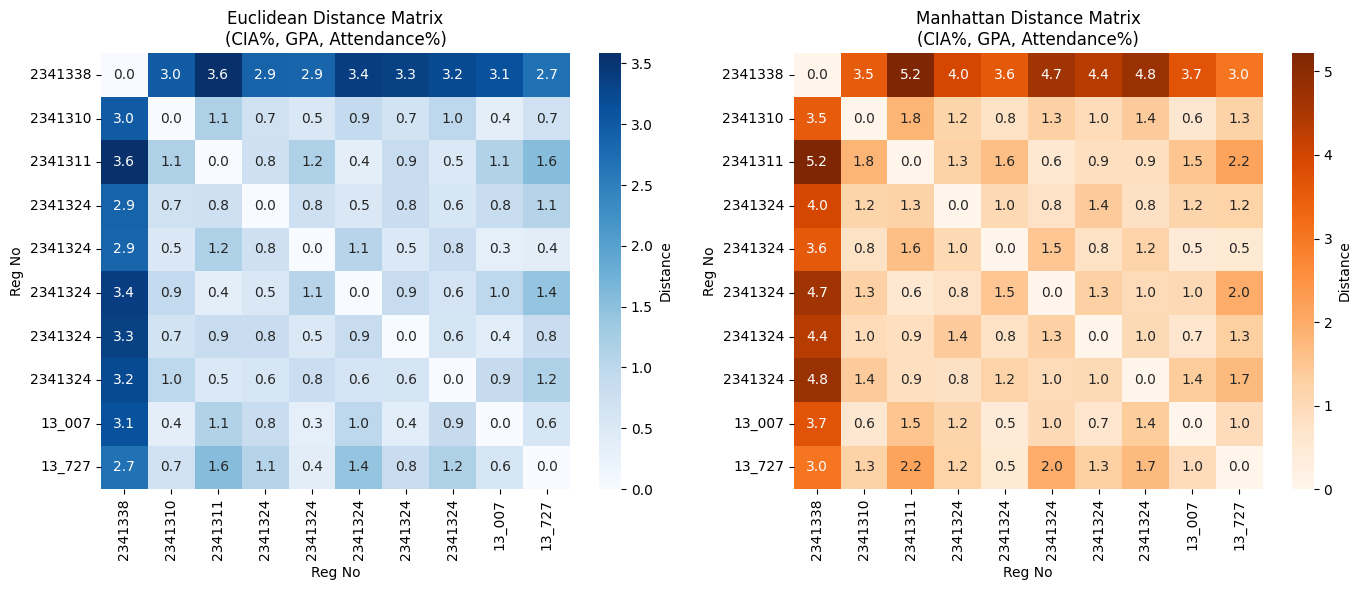

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
sns.heatmap(euclidean_df, annot=True, fmt=".1f", cmap="Blues", ax=axes[0], cbar_kws={"label": "Distance"})
axes[0].set_title("Euclidean Distance Matrix\n(CIA%, GPA, Attendance%)")
axes[0].set_xlabel("Reg No")
axes[0].set_ylabel("Reg No")
 
sns.heatmap(manhattan_df, annot=True, fmt=".1f", cmap="Oranges", ax=axes[1], cbar_kws={"label": "Distance"})
axes[1].set_title("Manhattan Distance Matrix\n(CIA%, GPA, Attendance%)")
axes[1].set_xlabel("Reg No")
axes[1].set_ylabel("Reg No")
 
plt.tight_layout()
plt.savefig("/Users/bhagyasree/Codes/ML/LAB2/distance_matrices_heatmap.png", dpi=150)
print("\nSaved heatmap to distance_matrices_heatmap.png")

In [30]:
i, j = 0, 1
print(f"\nExample interpretation: distance between student {labels_demo[i]} and {labels_demo[j]}")
print(f"  Euclidean : {euclidean_matrix[i, j]:.3f}")
print(f"  Manhattan : {manhattan_matrix[i, j]:.3f}")
print("Manhattan distance is generally >= Euclidean distance for the same pair of points,")
print("since it sums absolute per-feature differences instead of taking the straight-line path.")


Example interpretation: distance between student 2341338 and 2341310
  Euclidean : 2.990
  Manhattan : 3.508
Manhattan distance is generally >= Euclidean distance for the same pair of points,
since it sums absolute per-feature differences instead of taking the straight-line path.
